In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")


PyTorch version: 2.5.0+cpu
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [3]:
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

In [4]:
import sys
from pathlib import Path

_cwd = Path().resolve()
_candidates = (_cwd, _cwd.parent)
for _root in _candidates:
    if (_root / 'node_diffusion').exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
else:
    raise ModuleNotFoundError("Could not locate 'node_diffusion' package; adjust sys.path.")

del _cwd, _candidates, _root


# Code

In [5]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['label'] += offset
        out_graphs.append(graph.copy())
    return out_graphs, targets

In [6]:
from coco_grape.visualizer.display import draw_graphs
def plot_sample(sampled_graphs, sampled_targets, haystack=None, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    gs = pos_graphs + neg_graphs
    if haystack is not None:
        ts = list(compute_is_valid(pos_graphs, haystack)) + list(compute_is_valid(neg_graphs, haystack))
        draw_graphs(gs, ts, n_graphs_per_line=n_graphs_per_line)
    else:
        draw_graphs(gs, n_graphs_per_line=n_graphs_per_line)

In [7]:
def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    return pos_graphs, neg_graphs

In [8]:
import math
import hashlib
import matplotlib.pyplot as plt
import networkx as nx
from coco_grape.visualizer.mol_display import draw_molecules
    
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=4, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    """
    Plot a list of NetworkX graphs in a grid.
    
    Each node is drawn with a color determined by its 'label' attribute.
    The color is chosen persistently (so nodes with the same label always get the same color)
    and then lightened by the given factor.
    
    Parameters:
        graphs (list): List of networkx.Graph objects.
        cmap: Matplotlib colormap or a string name for a colormap. Defaults to 'Set2'.
        light (float): A value in [0, 1] used to lighten colors 
                       (0 leaves the color unchanged, 1 turns it white). Defaults to 0.3.
        size (int, optional): Size (in inches) for each individual square plot (default: 4).
        n_cols (int, optional): Number of columns in the grid. If None, defaults to the number of graphs.
        show_label (bool, optional): If True, displays the node's label on the plot.
    """
    if mode == 'molecule':
        draw_molecules(graphs)
        return
        
    # If cmap is given as a string, get the corresponding matplotlib colormap
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
        
    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)
    
    # Create subplots with no border on the plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    
    # Ensure axes is a flat list (handle case with one or multiple rows/cols)
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes.flatten())
    else:
        axes = axes.flatten()
    
    def get_color_for_label(label):
        """
        Given a label (string), returns a persistent color based on a hash.
        The base color is obtained from the cmap and then lightened.
        """
        label_str = str(label)
        # Use MD5 for a deterministic hash (consistent across invocations)
        hash_val = hashlib.md5(label_str.encode('utf-8')).hexdigest()
        numeric_hash = int(hash_val, 16)+color_offset
        # Normalize to [0, 1] using mod 1000 for a quick spread
        normalized = (numeric_hash % 1000) / 999.0
        base_color = cmap(normalized)  # returns an RGBA tuple
        
        # Lighten the color: interpolate between base_color and white (1,1,1)
        lightened = tuple((1 - light) * base_color[i] + light for i in range(3))
        # Preserve alpha if available
        if len(base_color) == 4:
            lightened += (base_color[3],)
        return lightened

    # Loop over each graph and plot it on its corresponding axis
    for i, G in enumerate(graphs):
        ax = axes[i]
        ax.axis('off')  # Remove borders/ticks
        
        # Compute layout using the Kamada–Kawai algorithm
        pos = nx.kamada_kawai_layout(G)
        
        # Get colors for nodes using the node's 'label' attribute
        node_colors = []
        labels = {}
        for n in G.nodes():
            label = G.nodes[n].get('label', '')
            node_colors.append(get_color_for_label(label))
            labels[n] = str(label)
            
        # Draw edges and nodes with a black border for each node
        nx.draw_networkx_edges(G, pos, width=2, ax=ax)
        nx.draw_networkx_nodes(
            G, pos, ax=ax, node_color=node_colors, edgecolors='black', linewidths=2,
        )
        
        # Optionally, draw labels if show_label is True
        if show_label:
            nx.draw_networkx_labels(G, pos, labels=labels, ax=ax)
    
    # Hide any unused axes if the grid is larger than the number of graphs
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


In [9]:
def show_samples(n_samples, graphs, targets, graph_generator):
    neg_graphs = [graph for graph, target in zip(graphs, targets) if target==0]
    pos_graphs = [graph for graph, target in zip(graphs, targets) if target!=0]

    print("Positive Graphs:")
    plot_networkx_graphs(pos_graphs[:n_samples], n_cols=n_samples)
    sampled_graphs = graph_generator.sample_conditioned_on_random(pos_graphs, n_samples)
    print("Sampled Positive Graphs:")
    plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

    print("Negative Graphs:")   
    plot_networkx_graphs(neg_graphs[:n_samples], n_cols=n_samples)
    sampled_graphs = graph_generator.sample_conditioned_on_random(neg_graphs, n_samples)
    print("Sampled Negative Graphs:")
    plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

In [10]:
def graph_label_histogram(graph, label_classes):
    hist = np.zeros(len(label_classes), dtype=float)
    class_to_idx = {label: idx for idx, label in enumerate(label_classes)}
    for _, data in graph.nodes(data=True):
        label = data.get("label")
        if label in class_to_idx:
            hist[class_to_idx[label]] += 1.0
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def summarize_label_histogram_alignment(graph_generator, graphs, n_compare=16):
    eqm_generator = graph_generator.node_generator.conditional_node_generator
    label_classes = [int(label) if isinstance(label, np.integer) else label for label in eqm_generator.node_label_classes_]
    print("Label vocabulary:", label_classes)

    input_graphs = graphs[:n_compare]
    graph_conditioning = graph_generator.graph_encode(input_graphs)
    conditioning_histograms = np.vstack([
        graph_label_histogram(graph, label_classes) for graph in input_graphs
    ])
    print(
        "Conditioning histogram from first real graph:",
        {label: float(value) for label, value in zip(label_classes, conditioning_histograms[0].round(3))},
    )

    generated_graphs = graph_generator.decode(graph_conditioning)
    generated_histograms = np.vstack([
        graph_label_histogram(graph, label_classes) for graph in generated_graphs
    ])
    histogram_diff = generated_histograms - conditioning_histograms
    abs_diff = np.abs(histogram_diff)

    summary = {
        "label_classes": label_classes,
        "mean_conditioning": conditioning_histograms.mean(axis=0),
        "mean_generated": generated_histograms.mean(axis=0),
        "mean_diff": histogram_diff.mean(axis=0),
        "mean_abs_diff": abs_diff.mean(axis=0),
        "average_l1_error": abs_diff.sum(axis=1).mean(),
    }
    summary["mistake_order"] = np.argsort(-summary["mean_abs_diff"])

    print("Mean conditioning histogram:", {label: float(value) for label, value in zip(label_classes, summary["mean_conditioning"].round(3))})
    print("Mean generated histogram:", {label: float(value) for label, value in zip(label_classes, summary["mean_generated"].round(3))})
    print("Average L1 histogram error per graph:", round(float(summary["average_l1_error"]), 4))
    print("Most mistaken labels:")
    for idx in summary["mistake_order"][: min(10, len(label_classes))]:
        print(
            f"  {label_classes[idx]}: mean_abs_diff={summary['mean_abs_diff'][idx]:.4f}, "
            f"generated-conditioning={summary['mean_diff'][idx]:+.4f}"
        )
    return summary

def plot_label_histogram_alignment(summary):
    label_classes = summary["label_classes"]
    mean_conditioning = summary["mean_conditioning"]
    mean_generated = summary["mean_generated"]
    mean_abs_diff = summary["mean_abs_diff"]
    mean_diff = summary["mean_diff"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    x = np.arange(len(label_classes))
    width = 0.38

    axes[0].bar(x - width / 2, mean_conditioning, width, label="conditioning")
    axes[0].bar(x + width / 2, mean_generated, width, label="generated")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(label_classes, rotation=45, ha="right")
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Average label histogram")
    axes[0].legend()

    axes[1].bar(x, mean_abs_diff, color="tomato")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(label_classes, rotation=45, ha="right")
    axes[1].set_ylim(0, max(0.05, mean_abs_diff.max() * 1.2))
    axes[1].set_title("Average absolute histogram difference")

    axes[2].bar(x, mean_diff, color=["seagreen" if v >= 0 else "firebrick" for v in mean_diff])
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(label_classes, rotation=45, ha="right")
    axes[2].set_title("Signed histogram bias")

    plt.tight_layout()
    plt.show()


---

# Data

In [11]:
DATASET_TYPE = 'MOLECULAR'

In [12]:
DATASET_TYPE = 'ARTIFICIAL'

In [13]:
def build_dataset(dataset_size=50):
    if DATASET_TYPE == 'ARTIFICIAL':
        from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor
        graph_types = ['path', 'tree', 'cycle', 'degree', 'regular', 'dense']
        alphabet_size = 3
        size = 5
        graphs, targets = ArtificialGraphDatasetConstructor(
            graph_generator_target_type_pos='cycle', 
            graph_generator_context_type_pos='cycle', 
            graph_generator_target_type_neg='tree',
            graph_generator_context_type_neg='tree', 
            target_size_pos=size, 
            context_size_pos=size, 
            n_link_edges_pos=1,
            alphabet_size_pos=alphabet_size,
            target_size_neg=size, 
            context_size_neg=size, 
            n_link_edges_neg=1,
            alphabet_size_neg=alphabet_size).sample(dataset_size//2)

        graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)

        from coco_grape.utils.canonical_order import canonicalise
        #graphs = [canonicalise(graph) for graph in graphs]

        #graph_array = np.empty(len(graphs), dtype=object)
        #for i, graph in enumerate(graphs): graph_array[i] = graph
        #graphs = graph_array
        #haystack = np.unique(make_graph_signature_mtx(graphs),axis=0)
        #print('dataset has %d different templates'%len(haystack))
        print('#graphs:%d'%(len(graphs)))
        
        n_graphs_per_line = 8
        pos_graphs, neg_graphs = select_pos_neg(graphs, targets, n_lines=1, n_graphs_per_line=n_graphs_per_line)
        #plot_sample(graphs, targets, haystack)
        plot_networkx_graphs(pos_graphs, n_cols=n_graphs_per_line)
        plot_networkx_graphs(neg_graphs, n_cols=n_graphs_per_line)
        

    elif DATASET_TYPE == 'MOLECULAR':
        from coco_grape.visualizer.mol_display import draw_molecules
        
        from coco_grape.data_loader.mol.mol_loader import PubChemLoader
        assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213','651610', '630']
        from coco_grape.data_loader.loader import SupervisedDataSetLoader
        assay_id=assay_ids[-4]
        assay_id = '651610'
        def pubchem_loader(): return PubChemLoader().load(assay_id)
        original_graphs, original_targets = SupervisedDataSetLoader(pubchem_loader, size=dataset_size, use_equalized=False).load()
        original_graphs = np.array(original_graphs, dtype=object)
        original_targets = np.array(original_targets)
        print('#graphs:%d   class split:%s'%(len(original_graphs), np.bincount(original_targets)))


        max_node_size = 19
        print('...filter by size <= %d'%max_node_size)
        idxs = [idx for idx, graph in enumerate(original_graphs) if nx.number_of_nodes(graph)<=max_node_size]
        print('#graphs:%d '%(len(idxs)))
        graphs = original_graphs[idxs].tolist()
        targets = original_targets[idxs]

        from coco_grape.visualizer.mol_display import draw_molecules
        draw_molecules(graphs[:7*2])
    return graphs, targets

---

# Experiment

In [14]:
nbits = 11
verbose = 2

import sys

sys.path.insert(0, "/home/fabrizio/sync/Projects/NSPPK")
from nsppk import NSPPK, NodeNSPPK

node_graph_vectorizer = NodeNSPPK(
    radius=2,  # Maximum rooted-neighborhood radius encoded around each node.
    distance=4,  # Maximum shortest-path distance used when pairing subgraphs.
    connector=1,  # Include one level of connector-path context between paired subgraphs.
    nbits=nbits,  # Hash-space width for the sparse structural features.
    dense=True,  # Return dense node feature arrays for the downstream generator.
    parallel=True,  # Encode graphs in parallel across CPU workers.
    use_edges_as_features=True,  # Include edge-labelled triplets in the structural encoding.
)
graph_vectorizer = NSPPK(
    radius=2,  # Maximum rooted-neighborhood radius encoded around each graph node.
    distance=4,  # Maximum shortest-path distance used when aggregating paired subgraphs.
    connector=1,  # Include one level of connector-path context between paired subgraphs.
    nbits=nbits,  # Hash-space width for the sparse structural features.
    dense=True,  # Return dense graph-level conditioning vectors.
    parallel=True,  # Encode graphs in parallel across CPU workers.
    use_edges_as_features=True,  # Include edge-labelled triplets in the structural encoding.
)

from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    FeasibilityEstimatorNumberOfNodesInRange,
    WithinRangeFeasibilityEstimatorFromNumericalFunction
)
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel

feasibility_size = WithinRangeFeasibilityEstimatorFromNumericalFunction(numerical_function=lambda graph: len(graph), quantile=None)
df = compose(neighborhood(radius=2), unlabel())
feasibility_unlabeled_structure = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=df,
    nbits=19,
    parallel=True,
    backend="dill",
)
df = neighborhood(radius=1)
feasibility_valence = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=df,
    nbits=19,
    parallel=True,
    backend="dill",
)
df = cycle()
feasibility_cycle = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=df,
    nbits=19,
    parallel=True,
    backend="dill",
)
feasibility_estimators = [feasibility_valence]
feasibility_estimator = FeasibilityEstimator(feasibility_estimators)


from node_diffusion.eqm_conditional_node_generator import EqMConditionalNodeGenerator
conditional_node_generator_model = EqMConditionalNodeGenerator(
    latent_embedding_dimension=128,  # Width of the latent node representation processed by the transformer.
    number_of_transformer_layers=4,  # Number of shared cross-attention transformer blocks.
    transformer_attention_head_count=4,  # Attention heads used inside each transformer block.
    transformer_dropout=0.2,  # Dropout applied in transformer and auxiliary heads.
    learning_rate=1e-4,  # Optimizer learning rate for Lightning training.
    maximum_epochs=250,  # Maximum number of training epochs before stopping.
    batch_size=16,  # Number of graphs per optimization step.
    total_steps=100,  # Number of EqM sampling steps used at generation time.
    verbose=verbose,  # Whether to print training and decoding diagnostics.
    verbose_epoch_interval=10,  # Print train/validation summaries every 10 epochs when verbose >= 2.
    enable_early_stopping=True,  # Stop training when validation total loss stops improving.
    early_stopping_monitor="val_total",  # Validation metric used for both checkpointing and early stopping.
    early_stopping_mode="min",  # Lower validation total loss is better.
    early_stopping_patience=10,  # Number of validation epochs without improvement before stopping.
    early_stopping_min_delta=0.0,  # Minimum improvement required to reset early-stopping patience.
    restore_best_checkpoint=True,  # Reload the best validation checkpoint into memory after fitting.
    lambda_degree_importance=5e3,  # Weight on the degree classification loss; reduced to limit degree overfitting.
    lambda_node_exist_importance=0,  # Weight on the node-existence loss.
    lambda_node_label_importance=1e4,  # Weight on the node-label loss so labels matter comparably to degree/edge terms.
    lambda_edge_label_importance=5e3,  # Weight on the edge-label loss when edge labels are available.
    lambda_locality_importance=1e4,  # Weight on the direct edge-presence supervision loss.
    degree_temperature=1,  # Temperature applied to the degree logits before cross-entropy.
    use_guidance=False,  # Disable classifier guidance during sampling.
    use_locality_supervision=True,  # Train the generator to predict edge presence.
    eqm_sigma=0.2,  # Noise scale used by the EqM score-matching objective.
    sampling_step_size=0.05,  # Step size for EqM sampling updates.
    langevin_noise_scale=0.0,  # Extra Langevin noise injected during sampling.
)

from node_diffusion.graph_generator import ConditionedNodeGenerator
node_generator = ConditionedNodeGenerator(
    conditional_node_generator=conditional_node_generator_model, 
    verbose=verbose)

from node_diffusion.graph_generator import GraphDecoder
graph_decoder = GraphDecoder(
    verbose=verbose,
    enforce_connectivity=True, #Whether to enforce a single connected component.
    warm_start_mst=True, #Whether to warm start solver using maximum spanning tree.
    )

from node_diffusion.graph_generator import GraphGenerator
graph_generator = GraphGenerator(
    graph_vectorizer=graph_vectorizer,
    node_graph_vectorizer=node_graph_vectorizer, 
    node_generator=node_generator,
    graph_decoder=graph_decoder,
    use_locality_supervision=True,
    locality_sample_fraction=0.5,  # Fraction of candidate edge-supervision pairs retained each epoch.
    locality_horizon=1,
    negative_sample_factor=1, #How many negative locality pairs to sample per positive pair before subsampling.
    locality_sampling_strategy="stratified_preserve", #How to subsample locality pairs while controlling class balance.
    locality_target_positive_ratio=0.5, #Target positive ratio used only when locality_sampling_strategy="stratified_target".
    feasibility_estimator=feasibility_estimator,  # Reject infeasible generated graphs and resample until the batch is filled.
    max_feasibility_attempts=20,  # Guardrail on how many rejection-sampling passes to allow per generation call.
    verbose=verbose)

---

#graphs:480


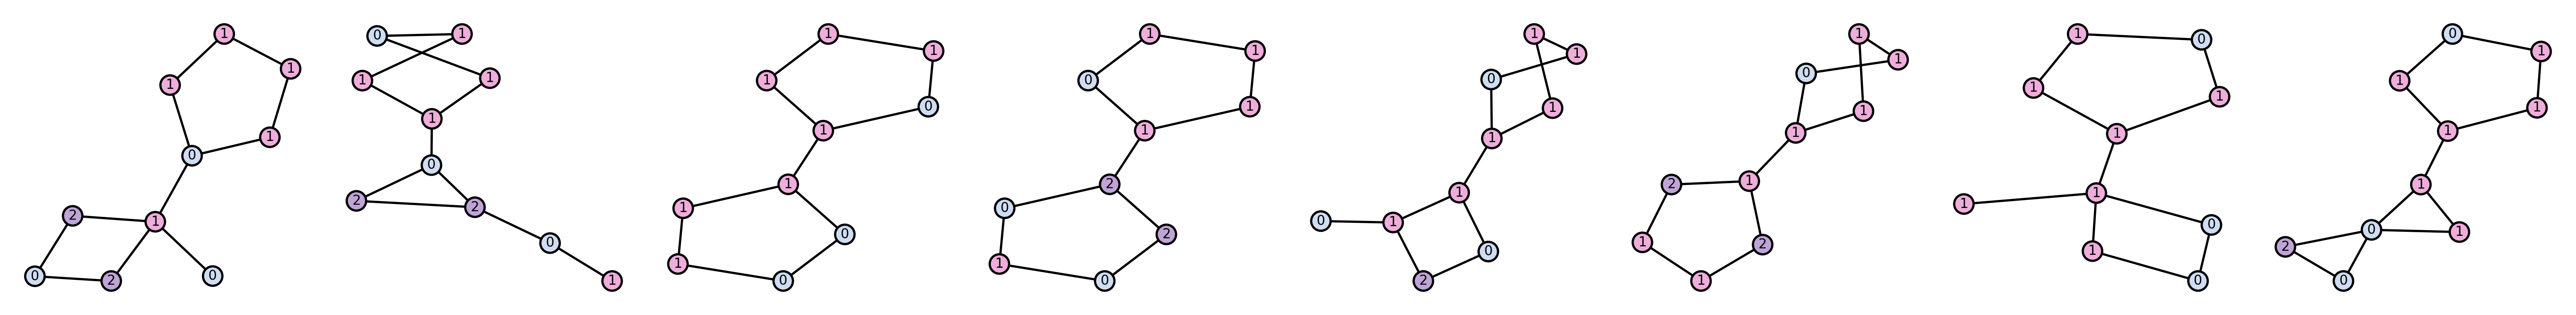

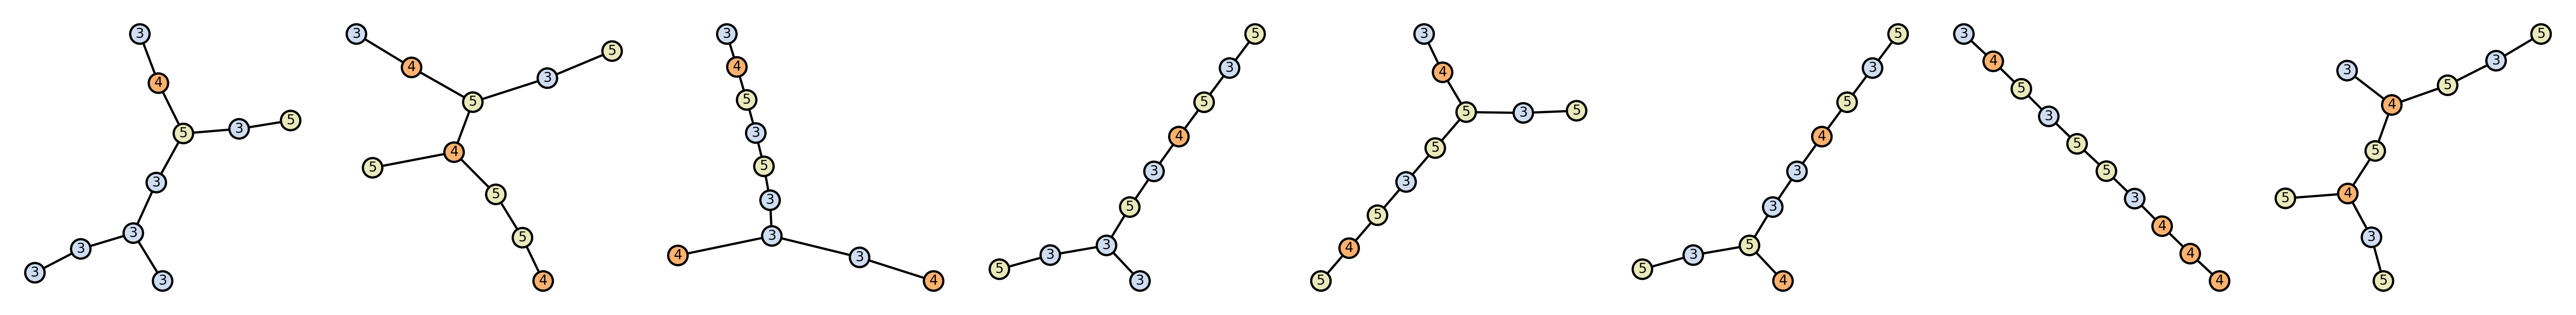

train_graphs:470   test_graphs:10


In [15]:
graphs, targets = build_dataset(dataset_size=500)

from sklearn.model_selection import train_test_split
# Assuming `graphs` and `targets` are lists or numpy arrays
train_graphs, test_graphs, train_targets, test_targets = train_test_split(
    graphs, targets, test_size=10, random_state=42  # Adjust test_size as needed
)
print(f'train_graphs:{len(train_graphs)}   test_graphs:{len(test_graphs)}')

In [ ]:
%%time
graph_generator.fit(train_graphs)


Fitting model on 470 graphs
Fitting feasibility estimator on 470 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 6 node labels detected.
  edge_labels: mode=constant, enabled. All labelled edges share one label.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 28068 pairs (50.00%) from 56136 total pairs (pos=18844, neg=37292, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=9422, neg=18646, positive_ratio=0.336.
Training conditional model on 470 graphs with up to 10 nodes each.
Using direct-edge supervision with 28068 labelled pairs.
Existence supervision disabled: all training graphs have the same node count and the valid existence target is constant.
Di

## Conditioning vs Generated Label Histograms

In [ ]:
label_histogram_summary = summarize_label_histogram_alignment(
    graph_generator,
    train_graphs,
    n_compare=5,
)
plot_label_histogram_alignment(label_histogram_summary)


In [ ]:
show_samples(n_samples=7, graphs=train_graphs, targets=train_targets, graph_generator=graph_generator)

In [ ]:
show_samples(n_samples=7, graphs=test_graphs, targets=test_targets, graph_generator=graph_generator)

---